<a href="https://colab.research.google.com/github/AHMADAMJAD0/Deep-Learning-/blob/main/10__Making_Neural_Networks_Fast_with_Vectorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

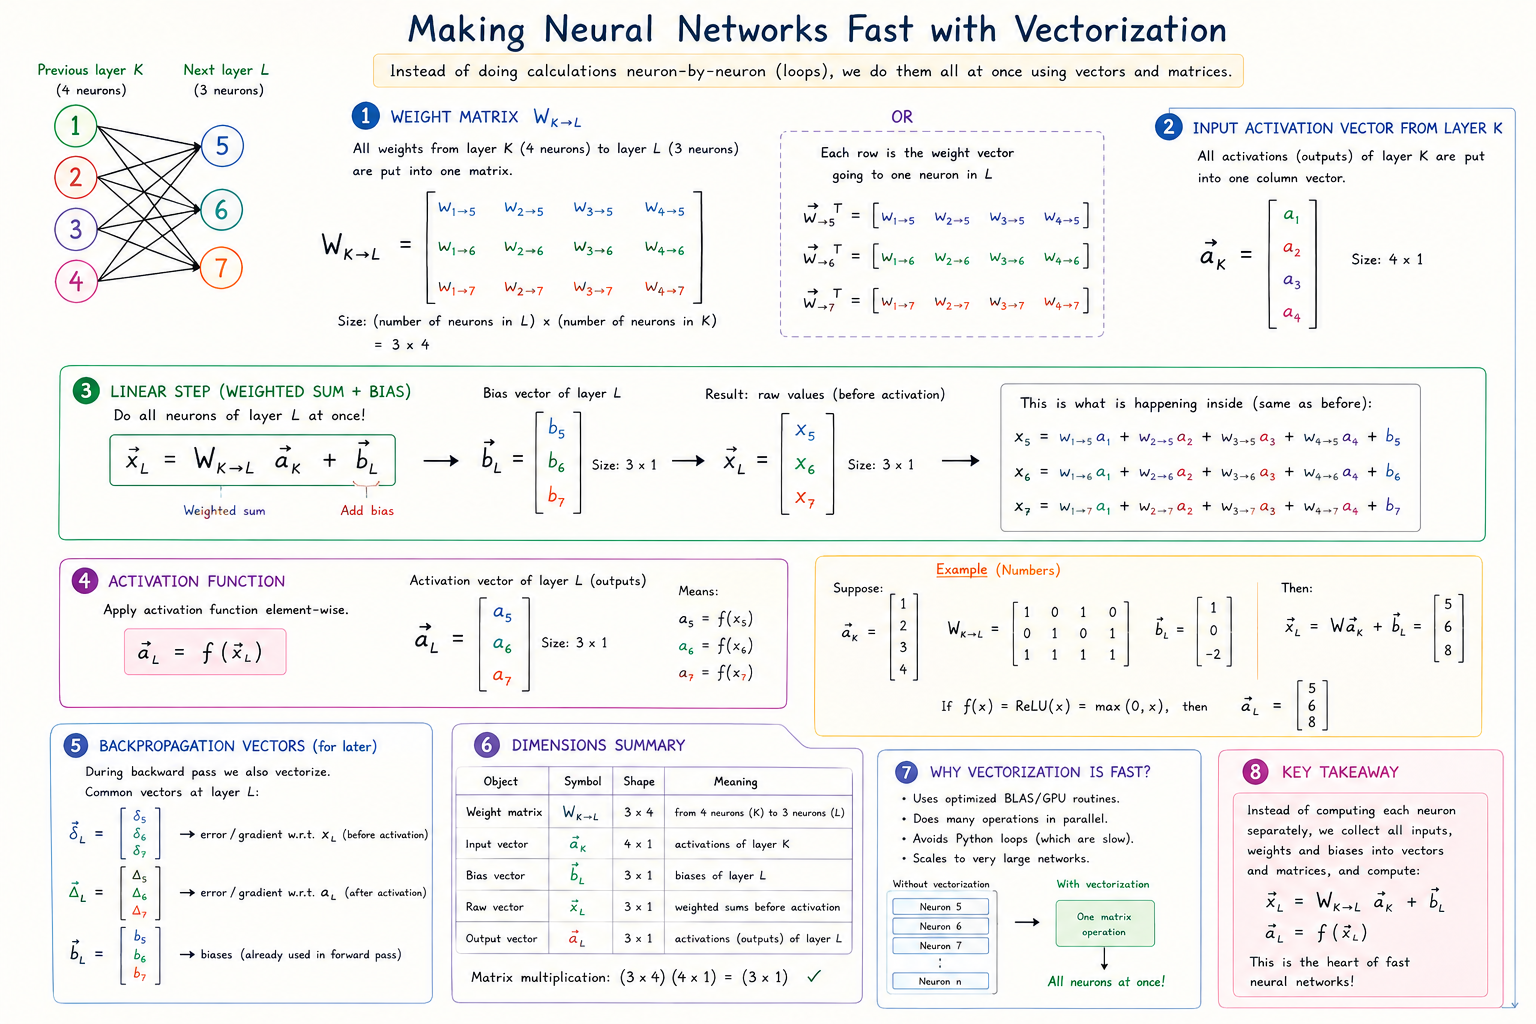

Vectorization ka simple matlab hai: ek-ek neuron ka calculation alag-alag loop mein karne ke bajaye, sab neurons ki calculations ko matrix/vector ki form mein ek saath karna. Isi se neural networks CPU/GPU par bohat fast chalte hain.

Aapki image mein left side par network hai:



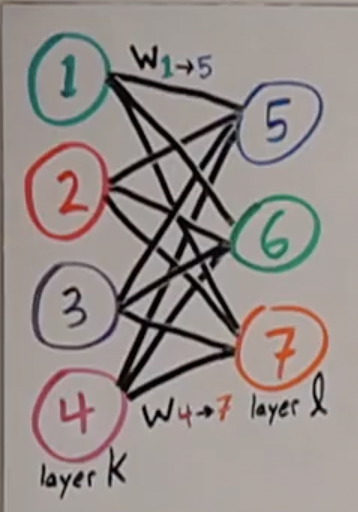

Yani:

Previous layer \(K\) mein 4 neurons
Next layer \(L\) mein 3 neurons

So architecture ka ye part hai:

$$ 4 \rightarrow 3 $$
Pehle without vectorization samjhein

Neuron 5 ko previous 4 neurons se values milengi:

$$ a_1,a_2,a_3,a_4 $$

Neuron 5 calculate karega:

$$ x_5= w_{1\to5}a_1+ w_{2\to5}a_2+ w_{3\to5}a_3+ w_{4\to5}a_4+ b_5 $$

Phir neuron 6 ke liye separately:

$$ x_6= w_{1\to6}a_1+ w_{2\to6}a_2+ w_{3\to6}a_3+ w_{4\to6}a_4+ b_6 $$

Phir neuron 7:

$$ x_7= w_{1\to7}a_1+ w_{2\to7}a_2+ w_{3\to7}a_3+ w_{4\to7}a_4+ b_7 $$

Yani hum baar baar same type ka calculation kar rahe hain:

Neuron 5 calculate karo

        ↓

Neuron 6 calculate karo

        ↓
        
Neuron 7 calculate karo

Ye kaam correct hai, lekin large neural network mein slow ho sakta hai.

Vectorization kya karegi?

Sab inputs ko ek vector bana do:

$$ \vec a_K= \begin{bmatrix} a_1\\ a_2\\ a_3\\ a_4 \end{bmatrix} $$

Sab biases:

$$ \vec b_L= \begin{bmatrix} b_5\\ b_6\\ b_7 \end{bmatrix} $$

Aur saare weights ko ek matrix mein arrange kar do:

$$ W= \begin{bmatrix} w_{1\to5} & w_{2\to5} & w_{3\to5} & w_{4\to5}\\ w_{1\to6} & w_{2\to6} & w_{3\to6} & w_{4\to6}\\ w_{1\to7} & w_{2\to7} & w_{3\to7} & w_{4\to7} \end{bmatrix} $$

Ab ek hi operation:

$$ \boxed{ \vec x_L=W\vec a_K+\vec b_L } $$

Aur result:

$$ \vec x_L= \begin{bmatrix} x_5\\ x_6\\ x_7 \end{bmatrix} $$

Yani ek matrix multiplication ne 3 neurons ka weighted sum ek saath calculate kar diya.

Dimensions bhi image mein isi liye likhi hain

Weight matrix:

$$ W $$

ka size:

$$ 3\times4 $$

kyun ke:

3 neurons destination layer mein
4 neurons previous layer mein

Input activation vector:

$$ \vec a_K $$

size:

$$ 4\times1 $$

Multiply:

$$ (3\times4)(4\times1) $$

result:

$$ 3\times1 $$

Exactly:

$$ \begin{bmatrix} x_5\\ x_6\\ x_7 \end{bmatrix} $$

Yani dimensions perfectly match karti hain.

Phir activation function

Ab raw values mil gayin:

$$ \vec x_L= \begin{bmatrix} x_5\\ x_6\\ x_7 \end{bmatrix} $$

Ab ReLU maan lein:

$$ \vec a_L=f(\vec x_L) $$

Yani:

$$ \vec a_L= \begin{bmatrix} f(x_5)\\ f(x_6)\\ f(x_7) \end{bmatrix} $$

So:

Previous activations

[a₁ a₂ a₃ a₄]

       ↓

Weight Matrix W

       ↓
Matrix multiplication

       ↓

+ Bias vector

       ↓

[x₅ x₆ x₇]

       ↓

Activation function

       ↓
       
[a₅ a₆ a₇]


Chota numerical example

Suppose:

$$ \vec a_K= \begin{bmatrix} 1\\ 2\\ 3\\ 4 \end{bmatrix} $$

Aur weights:

$$ W= \begin{bmatrix} 1&0&1&0\\ 0&1&0&1\\ 1&1&1&1 \end{bmatrix} $$

Bias:

$$ b= \begin{bmatrix} 1\\ 0\\ -2 \end{bmatrix} $$

Ab:

$$ W\vec a_K $$

ek hi operation mein 3 neurons calculate karega.

Neuron 5:

$$ 1(1)+0(2)+1(3)+0(4)=4 $$

Neuron 6:

$$ 0(1)+1(2)+0(3)+1(4)=6 $$

Neuron 7:

$$ 1+2+3+4=10 $$

Bias add:

$$ \vec x_L= \begin{bmatrix} 5\\ 6\\ 8 \end{bmatrix} $$

Phir ReLU:

$$ \vec a_L= \begin{bmatrix} 5\\ 6\\ 8 \end{bmatrix} $$
Ye fast kyun hai?

Suppose aap ke network mein sirf 3 neurons nahi, balki:

$$ 10,000 $$

neurons hain.

Without vectorization:


Neuron 1 calculate

Neuron 2 calculate

Neuron 3 calculate
...
Neuron 10,000 calculate

Vectorization:

Ek bari matrix

      ↓

GPU ko do

      ↓

Thousands calculations parallel

      ↓

Result

GPU specially matrix multiplication mein bohat powerful hota hai.

Isi liye Deep Learning mein:

Vectors + Matrices = Speed
	​


Image mein \(\vec w_{\to5}\) kya hai?

Image mein neuron 5 ke saare incoming weights ko ek vector bana diya hai:

$$ \vec w_{\to5} = \begin{bmatrix} w_{1\to5}\\ w_{2\to5}\\ w_{3\to5}\\ w_{4\to5} \end{bmatrix} $$

Phir:

$$ x_5= \vec w_{\to5}^{\,T}\vec a_K+b_5 $$

Ye wahi purani calculation hai:

$$ w_{1\to5}a_1+ w_{2\to5}a_2+ w_{3\to5}a_3+ w_{4\to5}a_4+b_5 $$

Bas short vector notation mein.

Phir neuron 5, 6 aur 7 ke weight vectors ko ek saath rakh dein to weight matrix \(W\) ban jati hai.

Image mein ye 4 vectors bhi hain
$$ \vec a $$

= activation/output of neurons

$$ \vec x $$

= activation function se pehle weighted sums/raw values

$$ \vec b $$

= biases

$$ \vec\delta $$

= backward pass mein error/gradient-related values jo backpropagation mein use hoti hain.

Abhi forward pass ke liye sab se important:

$$ \boxed{ \vec x_L=W\vec a_K+\vec b_L } $$

phir:

$$ \boxed{ \vec a_L=f(\vec x_L) } $$

Ek line mein poora concept

Without vectorization:

Har neuron ko individually calculate karo

With vectorization:

Saare inputs → vector
Saare weights → matrix
Saare biases → vector
          ↓
Ek matrix operation
          ↓
Saare neurons ka result ek saath

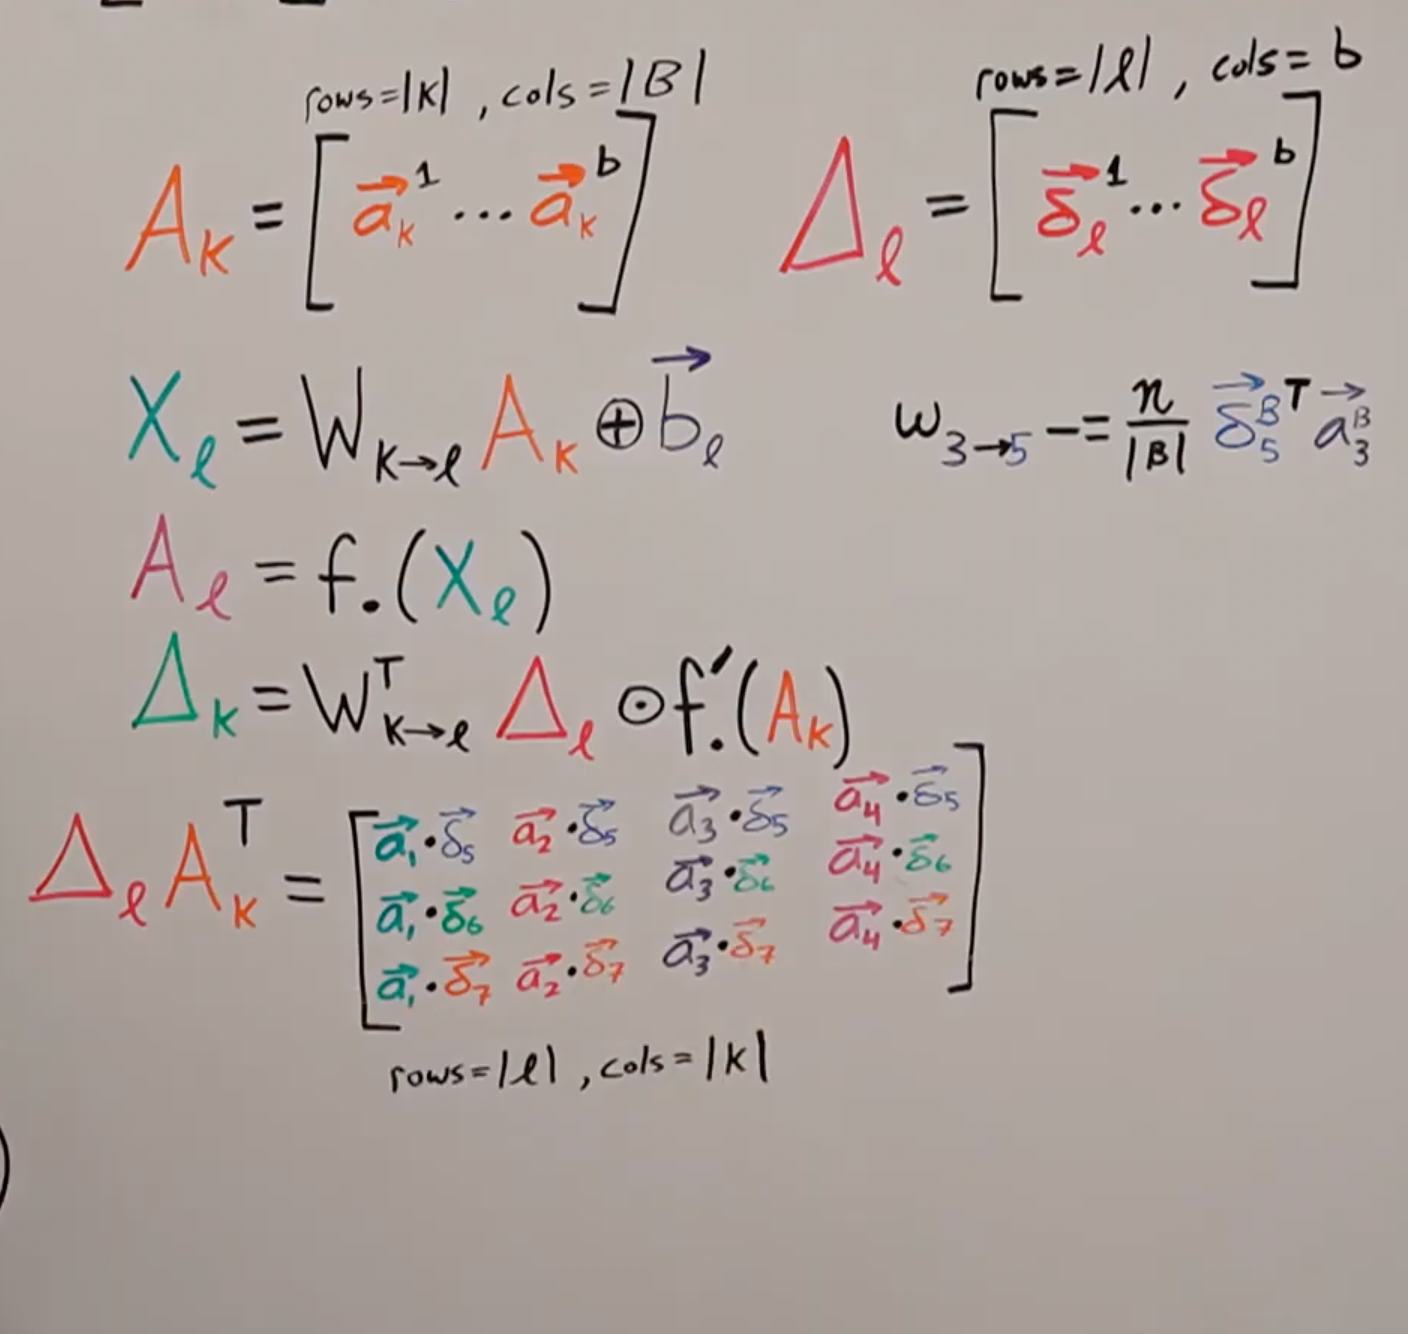

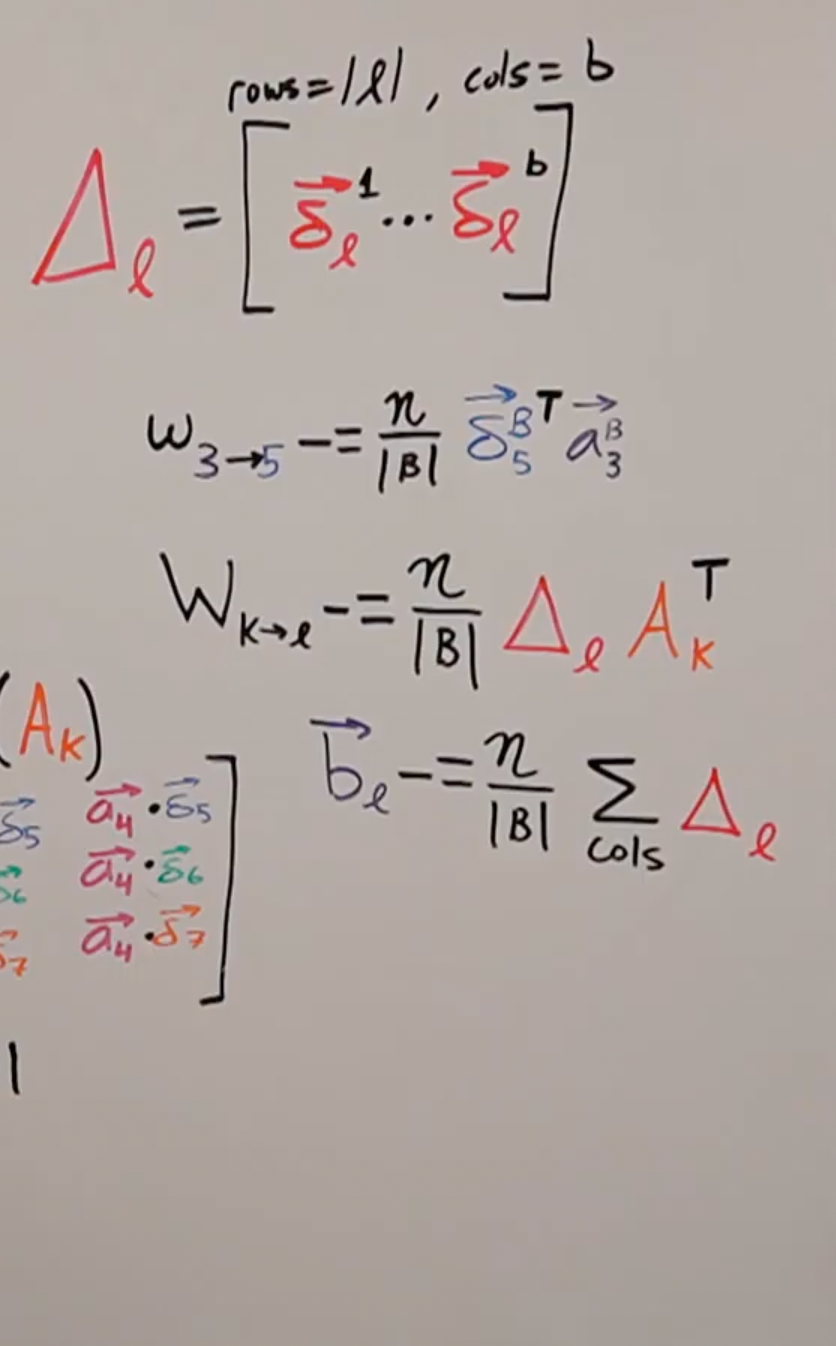

Ji. Ye dono images pichli vectorization ka next step hain. Pehle hum ek data point ko vector bana kar poori layer ek saath calculate kar rahe thay. Ab teacher keh raha hai:

Ek data point nahi — poora mini-batch bhi ek saath calculate aur train karo.

Isi wajah se ab vectors ki jagah matrices aa gayi hain.

Sab se pehle Batch \(B\) samjhein

Suppose hamare mini-batch mein 4 training examples hain:

Example 1

Example 2

Example 3

Example 4

To:

$$ |B|=4 $$

Har example ko separately neural network se pass karne ke bajaye:



Example 1 → network

Example 2 → network

Example 3 → network

Example 4 → network

hum kehte hain:

4 examples ko columns mein rakho

          ↓

Ek matrix operation

          ↓
          
4 examples ka forward pass ek saath

1. \(A_K\) kya hai?

Image ke top-left mein:

$$ A_K= \begin{bmatrix} \vec a_K^{\,1} & \vec a_K^{\,2} & \cdots & \vec a_K^{\,b} \end{bmatrix} $$

Pehle hamare paas ek example ke liye activation vector hota tha:

$$ \vec a_K $$

Ab batch mein bohat saare examples hain:

$$ \vec a_K^1,\vec a_K^2,\ldots,\vec a_K^b $$

Inko columns ke taur par side-by-side rakh diya.

Suppose layer \(K\) mein 4 neurons hain aur batch mein 3 examples:

$$ A_K= \begin{bmatrix} a_1^1&a_1^2&a_1^3\\ a_2^1&a_2^2&a_2^3\\ a_3^1&a_3^2&a_3^3\\ a_4^1&a_4^2&a_4^3 \end{bmatrix} $$

Dimensions:

$$ \boxed{|K|\times |B|} $$

Example:

$$ 4\times3 $$

Simple meaning:

Rows = neurons/features, columns = training examples.

2. Forward pass ab batch par

Pehle ek example ke liye:

$$ \vec x_L=W_{K\to L}\vec a_K+\vec b_L $$

Ab batch ke liye:

$$ \boxed{ X_L=W_{K\to L}A_K+\vec b_L } $$

Yahan:

\(W_{K\to L}\) = weights
\(A_K\) = poore batch ki activations
\(b_L\) = bias
\(X_L\) = poore batch ki raw/pre-activation values

Suppose:

$$ W:3\times4 $$

aur:

$$ A_K:4\times100 $$

agar batch size 100 hai.

Then:

$$ (3\times4)(4\times100) = 3\times100 $$

Yani:

$$ X_L:3\times100 $$

Ek matrix multiplication ne 100 examples ke 3 neurons calculate kar diye.

3. Image mein \(\oplus b_L\) kyun hai?

Bias vector suppose:

$$ \vec b_L= \begin{bmatrix} b_5\\ b_6\\ b_7 \end{bmatrix} $$

lekin \(X_L\) mein bohat sari columns hain.

To same bias ko har training example ke column mein add karte hain.

Conceptually:

$$ \begin{bmatrix} b_5\\b_6\\b_7 \end{bmatrix} $$

ko har column ke saath add kiya jata hai.

Isko programming mein aksar:

$$ \boxed{\text{broadcasting}} $$

kehte hain.

4. Activation function

Ab:

$$ X_L $$

mil gaya.

Phir:

$$ \boxed{ A_L=f(X_L) } $$

Activation function har element par separately lagti hai.

Agar ReLU hai:

$$ ReLU(x)=\max(0,x) $$

to \(X_L\) matrix ke har number par ReLU apply hogi.

Example:

$$ X_L= \begin{bmatrix} 2&-1\\ -3&5 \end{bmatrix} $$

ReLU:

$$ A_L= \begin{bmatrix} 2&0\\ 0&5 \end{bmatrix} $$

Yani forward pass:

A_K

 ↓

W A_K + b

 ↓

X_L

 ↓

Activation

 ↓

A_L

5. Ab \(\Delta_L\) kya hai?

Yahan se backpropagation start ho rahi hai.

Image mein:

$$ \Delta_L= \begin{bmatrix} \vec\delta_L^1& \cdots& \vec\delta_L^b \end{bmatrix} $$

Ye basically poore batch ke error/gradient signals hain.

Jaise \(A_K\) mein har column ek example tha, waise hi:

$$ \Delta_L $$

mein bhi har column ek example ka backward error hai.

Simple:

A_K = forward information

Δ_L = backward error information


Dimensions:

$$ \boxed{|L|\times |B|} $$

Agar layer \(L\) mein 3 neurons aur batch mein 100 examples:

$$ \Delta_L=3\times100 $$
6. **Error previous layer mein kaise jata hai?**

Image mein:

$$ \boxed{ \Delta_K= W_{K\to L}^{T} \Delta_L \odot f'(\cdot) } $$

Ye backpropagation hai.

Simple language mein:

Layer \(L\) ki ghalti ko weights ke through peeche layer \(K\) mein bhejo, phir activation function ke derivative se adjust karo.

Flow:

Δ_L

 ↓

Weights ka transpose Wᵀ

 ↓

Previous layer ko error distribute

 ↓

Activation derivative

 ↓

Δ_K

Yani:

$$ \boxed{\text{Backpropagation: error output side se input side ki taraf}} $$
7. Ab weights ka gradient kaise nikal raha hai?

Ye image ka sab se important part hai:

$$ \boxed{ \Delta_L A_K^T } $$

Ye matrix saare weights ke gradients ek saath nikal deti hai.

Dimensions check karein:

$$ \Delta_L: |L|\times|B| $$

Aur:

$$ A_K^T: |B|\times|K| $$

Multiply:

$$ (|L|\times|B|) (|B|\times|K|) $$

Result:

$$ \boxed{|L|\times|K|} $$

Exactly weight matrix ke same dimensions!

Isliye:

$$ \boxed{ \frac{\partial L}{\partial W} \propto \Delta_L A_K^T } $$
8. Is multiplication ka actual meaning kya hai?

Suppose specific weight hai:

$$ w_{3\to5} $$

Yani neuron 3 se neuron 5.

Is weight ka gradient batch ke sab examples se aata hai.

Example 1:

$$ a_3^1\delta_5^1 $$

Example 2:

$$ a_3^2\delta_5^2 $$

Example 3:

$$ a_3^3\delta_5^3 $$

...

Sab add:

$$ a_3^1\delta_5^1+ a_3^2\delta_5^2+ \cdots+ a_3^b\delta_5^b $$

Yahi dot product hai:

$$ \vec\delta_5^T\vec a_3 $$

Simple:

Har example ke liye Input × Error karo, phir poore batch ke results add karo.

Ye bilkul wahi concept hai jo humne beginning mein sikha tha:

$$ \boxed{\text{Weight gradient = Error × Input}} $$

Bas ab 100 examples ka Error × Input ek matrix multiplication mein ho raha hai.

9. \(\frac{1}{|B|}\) kyun?

Suppose batch size:

$$ |B|=100 $$

Hum 100 examples ke gradients ko combine kar rahe hain.

Usually unka average lete hain:

$$ \frac1{100} $$

Isliye:

$$ \boxed{ \frac{\partial L}{\partial W} = \frac1{|B|} \Delta_LA_K^T } $$

Agar image mein update directly likhi ho:

$$ W_{K\to L} \mathrel{-=} \frac{\eta}{|B|} \Delta_LA_K^T $$

iska matlab:

Batch ka gradient nikalo

       ↓

Average karo

       ↓

Learning rate η lagao

       ↓
       
Old weights se subtract

10. Weight update

Gradient descent:

$$ \boxed{ W_{\text{new}} = W_{\text{old}} - \eta \frac1{|B|} \Delta_LA_K^T } $$

Yahan:

\(W\) = saare weights
\(\eta\) = learning rate
\(\Delta_LA_K^T\) = batch se weight gradients

Sab weights ek saath update ho gaye.

Neuron-by-neuron nahi.

11. Bias update

Image mein:

$$ \boxed{ b_L \mathrel{-=} \frac{\eta}{|B|} \sum_{\text{columns}}\Delta_L } $$

Bias gradient mein input multiply nahi hota.

Aapko pehle yaad hoga:

$$ \text{Bias gradient} = \text{Error}\times1 $$

Isliye batch mein bas har neuron ke errors add karte hain.

Suppose neuron 5 ke batch errors:

$$ 0.2,\;-0.1,\;0.3 $$

Then:

$$ 0.2-0.1+0.3=0.4 $$

Average:

$$ \frac{0.4}{3} $$

Isi se \(b_5\) update hoga.



**Ab poori image ko ek story mein dekhein**

           MINI-BATCH
     Example 1 ... Example B
              ↓
        A_K matrix
              ↓
      W A_K + Bias
              ↓
           X_L
              ↓
      Activation f(X_L)
              ↓
           A_L
              ↓
     Network aage chalta hai
              ↓
          Prediction
              ↓
            Loss
              ↓
       BACKPROPAGATION
              ↓
           Δ_L
          ↙       ↘
       WᵀΔ_L      Δ_L A_Kᵀ
         ↓             ↓
      Δ_K         Weight gradient
                       ↓
                Weight update

Bias gradient = Δ_L ko
columns mein sum/average

Sab se important connection aapke previous concept se

Pehle ek example ke liye humne padha:

$$ \text{Weight gradient} = \text{Error}\times\text{Input} $$

Ab batch ke liye:

$$ \boxed{ \text{Weight gradient matrix} = \Delta_LA_K^T } $$

Yani ye koi nayi cheez nahi hai.

Bas:

Single example:
Error × Input

       ↓ vectorization ↓

100 examples:

Error Matrix × Input Matrixᵀ

Aur isi liye neural network fast train hota hai.

Final 6 cheezen yaad rakhein

Symbol	Simple meaning

\(A_K\)	Poore batch ki input/previous-layer activations

\(W\)	Layer ke saare weights

\(X_L\)	Activation se pehle raw values

\(A_L\)	Activation ke baad outputs

\(\Delta_L\)	Backward error/gradient signals

\(\Delta_LA_K^T\)	Saare weights ke gradients ek saath


Aur final training rule:

$$ \boxed{ \text{Forward: } A_K\rightarrow X_L\rightarrow A_L } $$ $$ \boxed{ \text{Backward: } \Delta_L\rightarrow\Delta_K } $$ $$ \boxed{ \text{Update: } W\leftarrow W-\eta\,\text{gradient} } $$

Yani vectorization sirf forward pass ko nahi, backpropagation aur weight updates ko bhi ek saath fast banati hai.